In [17]:
# Load dataset
import pandas as pd


df = pd.read_csv("online_shoppers_intention.csv")

X = df.drop("Revenue", axis=1)
y = df['Revenue'].astype(int)

# print(df.info())

print(X['PageValues'].unique())

# for col in df.columns:
#     print(col, df[col].unique(), "\n")

[ 0.         54.17976426 19.44707913 ... 78.81172527  3.68540082
 12.24171745]


In [3]:
# Split data into 80/20 ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
# Preprocessing & Model's Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


# need encode feature
need_encode = [col for col in X.select_dtypes(include=['str', 'bool']).columns]
# print(need_encode)

preprocessor = ColumnTransformer(
    transformers = [
        ('encode_feat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), need_encode)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocess', preprocessor), 
    ('model', RandomForestClassifier(oob_score=True, random_state=42))
])

In [5]:
# Finding the best Hyperparameter for the model
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold


param_grid = {
    "model__n_estimators" : [100, 200, 300],
    "model__class_weight" : ['balanced', 'balanced_subsample'],
    "model__max_depth" : [10, 15, 20, 30],
    "model__min_samples_split" : [2, 5, 10],
    "model__min_samples_leaf" : [1, 2, 4],
    "model__max_features" : ['sqrt', 'log2']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=25,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

In [6]:
# Train model
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced', 'balanced_subsample'], 'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum s

In [15]:
predictions = random_search.predict(X_test)
print(predictions)

# Best Hyperparameter found by RandomizeSearchCV
print("\n\n",random_search.best_params_)

best_estimator = random_search.best_estimator_
model = best_estimator.named_steps['model']

feature_names = best_estimator.named_steps['preprocess'].get_feature_names_out()
print(feature_names)

[0 0 1 ... 1 0 0]


 {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__class_weight': 'balanced'}
['encode_feat__Month' 'encode_feat__VisitorType' 'encode_feat__Weekend'
 'remainder__Administrative' 'remainder__Administrative_Duration'
 'remainder__Informational' 'remainder__Informational_Duration'
 'remainder__ProductRelated' 'remainder__ProductRelated_Duration'
 'remainder__BounceRates' 'remainder__ExitRates' 'remainder__PageValues'
 'remainder__SpecialDay' 'remainder__OperatingSystems'
 'remainder__Browser' 'remainder__Region' 'remainder__TrafficType']


In [8]:
# Classification Report and Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix


print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2084
           1       0.54      0.79      0.65       382

    accuracy                           0.86      2466
   macro avg       0.75      0.84      0.78      2466
weighted avg       0.89      0.86      0.87      2466



Confusion Matrix
[[1830  254]
 [  79  303]]


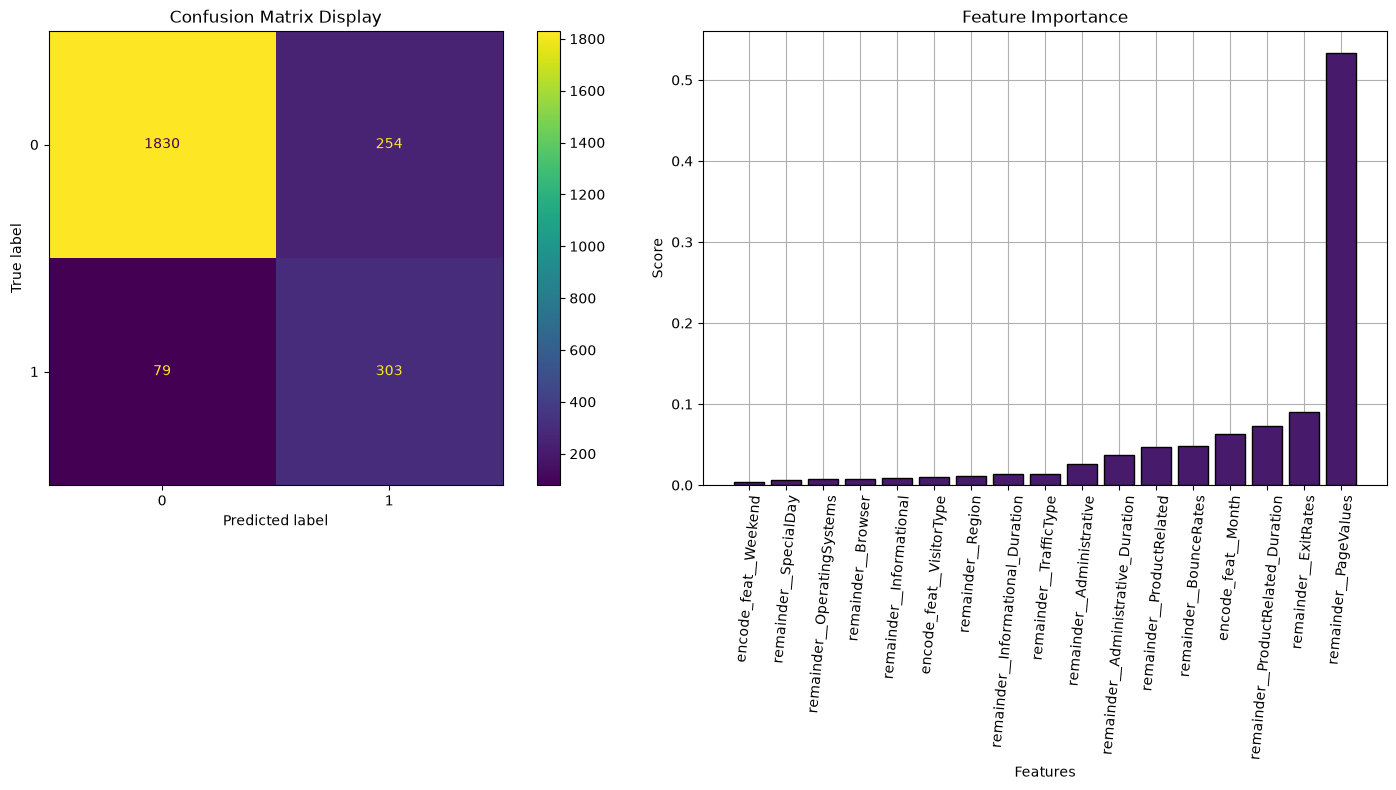

In [16]:
# Visualization 
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix Display")

# Plot Feature Importances
importance = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values()

axes[1].bar(importance.index, importance.values, color="#471A6B", edgecolor="#000000")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Score")
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].tick_params(axis='x', rotation=85)

plt.tight_layout()

[Text(0.5, 0.9, 'SpecialDay <= 0.025\ngini = 0.5\nsamples = 5182\nvalue = [4960, 4904]\nclass = Not Buy'),
 Text(0.25, 0.7, 'OperatingSystems <= 0.034\ngini = 0.495\nsamples = 4306\nvalue = [3887, 4717]\nclass = Buy'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'PageValues <= 1868.242\ngini = 0.324\nsamples = 2761\nvalue = [3386, 865]\nclass = Not Buy'),
 Text(0.0625, 0.3, 'Administrative_Duration <= 1.5\ngini = 0.263\nsamples = 2279\nvalue = [2872, 530]\nclass = Not Buy'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'ExitRates <= 55.5\ngini = 0.478\nsamples = 482\nvalue = [514, 335]\nclass = Not Buy'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'SpecialDay <= 0.0\ngini = 0.204\nsamples = 1545\nvalue = [501.0, 3852.0]\nclass = Buy'),
 Text(0.3125, 0.3, 'OperatingSystems <= 9.195\ngini = 0.12\nsamples = 811\nvalue = [157, 2302]\nclass = Buy'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 

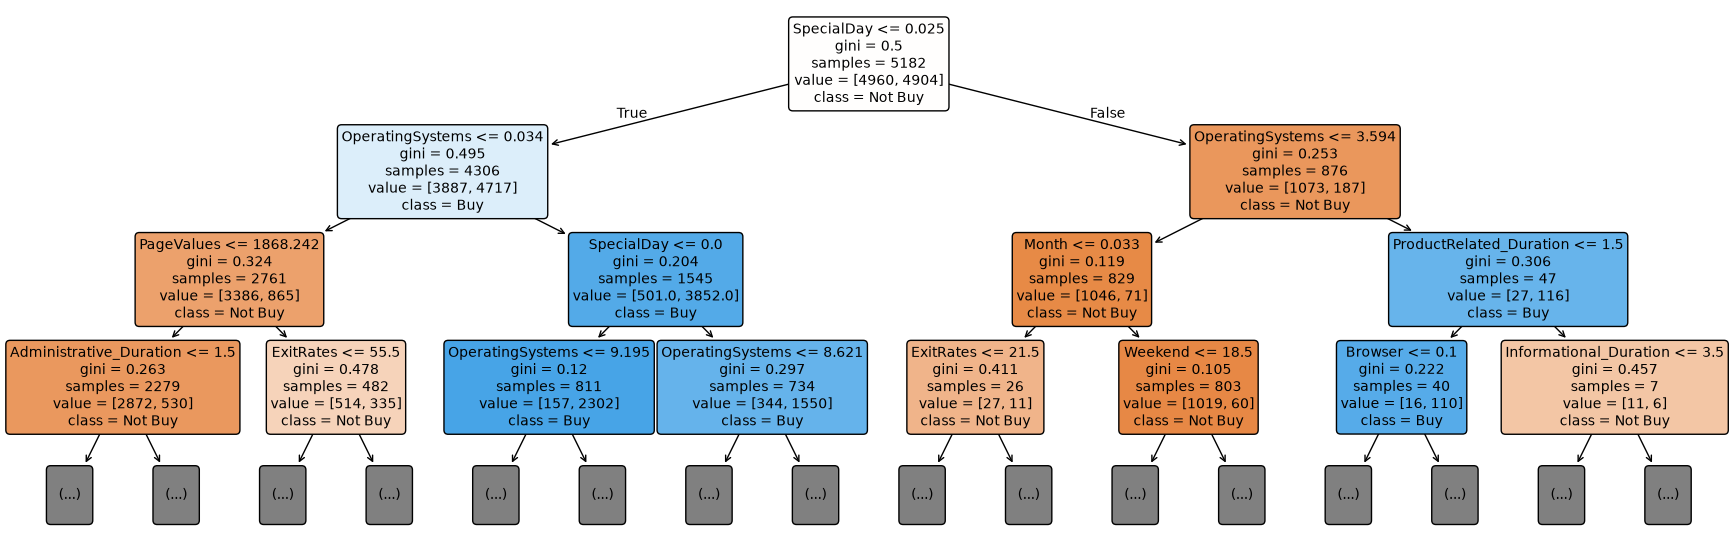

In [10]:
# Plot the 1st tree in the forest
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 7))

plot_tree(
    model.estimators_[0],
    max_depth=3,
    feature_names = X.columns,
    class_names=['Not Buy', 'Buy'],
    filled=True,
    rounded=True,
    fontsize=10
)